# Ritter Problem I — Live Walkthrough

A runnable companion to the *Clean Homotopy Algorithm* note. Each section
mirrors the corresponding section of the note, with a small code cell that
*demonstrates* the step on a concrete example.

**How to use this on a screenshare:** read the markdown out loud, run the cell
underneath, point at the numbers, move on. The final cell plots the entire
piecewise-linear optimizer path.

---

## The problem

Maximize a block-separable concave quadratic

$$
\max_{x_1,\ldots,x_k} \sum_{j=1}^k\left(c_j^T x_j - \tfrac12 x_j^T C_j x_j\right)
$$

subject to

$$
\sum_{j=1}^k A_j x_j \le b_0 \qquad\text{(coupling)},
\qquad
B_j x_j \le b_j,\ j=1,\ldots,k \qquad\text{(local)}.
$$

Each $C_j \succ 0$. The strict positive-definiteness is what makes the KKT
conditions *sufficient* — find a KKT point and you have the global optimum.

## Setup

We load the solver from `ritter_solver.py` (in the same folder as this
notebook). The module implements every step of the algorithm with names
matching the note: `a_j, d_j, P_j`, the master $H v = q^a + q^b t$, etc.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ritter_solver import (
    Problem, solve,
    free_max, residuals, relaxation_masks, initial_active_sets,
    block_affine, master_solve, collapse_to_t, find_next_breakpoint,
)

np.set_printoptions(precision=4, suppress=True)

## Example problem

Two blocks, $x_1 \in \mathbb{R}$ and $x_2 \in \mathbb{R}^2$. Two coupling
constraints, plus simple box bounds on each block.

$$
\max \ \underbrace{5 x_1 - \tfrac12 x_1^2}_{\text{block 1}}
     + \underbrace{3 y_1 + 4 y_2 - \tfrac12(2 y_1^2 + y_2^2)}_{\text{block 2},\ x_2 = (y_1,y_2)}
$$

subject to

$$
\begin{aligned}
x_1 + y_1 + y_2 &\le 3.5 & &\text{(coupling row 0)} \\
x_1 + y_1 + 2 y_2 &\le 5.0 & &\text{(coupling row 1)} \\
0 \le x_1 \le 3,\quad 0 \le y_1 \le 2,\quad 0 \le y_2 \le 2.
\end{aligned}
$$

This will produce **three** affine segments — the algorithm activates one
coupling row, then later drops another — so you'll see the active set change
in both directions.

In [2]:
# Block 1: scalar, x1 in R
C1 = np.array([[1.0]])
c1 = np.array([5.0])
B1 = np.array([[1.0], [-1.0]])         # x1 <= 3, -x1 <= 0
b1 = np.array([3.0, 0.0])

# Block 2: x2 in R^2 with y_1, y_2
C2 = np.array([[2.0, 0.0],
               [0.0, 1.0]])
c2 = np.array([3.0, 4.0])
B2 = np.vstack([-np.eye(2), np.eye(2)])  # 0 <= y_i <= 2
b2 = np.array([0.0, 0.0, 2.0, 2.0])

# Coupling
A1 = np.array([[1.0],
               [1.0]])
A2 = np.array([[1.0, 1.0],
               [1.0, 2.0]])
b0 = np.array([3.5, 5.0])

P = Problem(C=[C1, C2], c=[c1, c2], A=[A1, A2], B=[B1, B2], b0=b0, b=[b1, b2])
print(f"Problem set up: {P.k} blocks, {P.m0} coupling rows, "
      f"local rows = {[P.m(j) for j in range(P.k)]}")

Problem set up: 2 blocks, 2 coupling rows, local rows = [2, 4]


## Step 0 — Unconstrained block maxima

For each block, $x_j^{\rm free} = C_j^{-1} c_j$. If the resulting point is
feasible we're done.

In [3]:
x_free = free_max(P)
for j, xf in enumerate(x_free):
    print(f"x_{j}^free = {xf}")

ell0, ellj = residuals(P, x_free)
print(f"\nCoupling residual l_0 = {ell0}    (positive entries = violated)")
for j, lj in enumerate(ellj):
    print(f"Local residual l_{j}    = {lj}")
print("\nNot feasible: coupling rows 0 and 1 are both violated, "
      "and x_1 = 5 exceeds its upper bound of 3.")

x_0^free = [5.]
x_1^free = [1.5 4. ]

Coupling residual l_0 = [7.  9.5]    (positive entries = violated)
Local residual l_0    = [ 2. -5.]
Local residual l_1    = [-1.5 -4.  -0.5  2. ]

Not feasible: coupling rows 0 and 1 are both violated, and x_1 = 5 exceeds its upper bound of 3.


## Step 1 — Relaxation masks and $t_0$

Loosen exactly the violated rows by adding $e_i\, t$, with $e_i = 1$ if row $i$
is violated and $0$ otherwise. Choose $t_0$ as the worst violation so the free
point is feasible at $t = t_0$.

In [4]:
e0, ej, t0 = relaxation_masks(P, x_free)
print(f"Coupling mask e_0 = {e0}")
for j, e in enumerate(ej):
    print(f"Local mask    e_{j} = {e}")
print(f"\nt_0 = {t0:.6g}")

# Initial active sets: rows tight at t = t_0
I0, Ij = initial_active_sets(P, x_free, e0, ej, t0)
print(f"\nInitial I_0 = {set(I0)}")
for j, s in enumerate(Ij):
    print(f"Initial I_{j} = {set(s)}")

Coupling mask e_0 = [1. 1.]
Local mask    e_0 = [1. 0.]
Local mask    e_1 = [0. 0. 0. 1.]

t_0 = 9.5

Initial I_0 = {1}
Initial I_0 = set()
Initial I_1 = set()


## Step 8 — Solve each block in $(t, v)$

For block $j$ with current active local set $I_j$ and coupling set $I_0$, the
block KKT matrix is

$$
K_j = \begin{pmatrix} C_j & B_{j,I_j}^T \\ B_{j,I_j} & 0 \end{pmatrix},
$$

and three right-hand-side solves produce the affine coefficients of

$$
x_j(t, v) = a_j + d_j\, t - P_j\, v.
$$

Let's compute them for block 0 (and block 1) at the *initial* active set.

In [5]:
blocks_aff = [block_affine(P, j, Ij[j], I0, ej) for j in range(P.k)]

for j, (a, d, Pmat, r, s, Q) in enumerate(blocks_aff):
    print(f"--- block {j} ---")
    print(f"  a_{j} = {a}")
    print(f"  d_{j} = {d}")
    print(f"  P_{j} = {Pmat.ravel() if Pmat.size else 'empty'}")
    print(f"  (so x_{j}(t,v) = a_{j} + d_{j} t - P_{j} v)")

--- block 0 ---
  a_0 = [5.]
  d_0 = [0.]
  P_0 = [1.]
  (so x_0(t,v) = a_0 + d_0 t - P_0 v)
--- block 1 ---
  a_1 = [1.5 4. ]
  d_1 = [0. 0.]
  P_1 = [0.5 2. ]
  (so x_1(t,v) = a_1 + d_1 t - P_1 v)


## Step 9 — Master system $H v = q^a + q^b t$

Substitute the block formulas into the active coupling equations and collect
terms. The master coefficients are

$$
H = \sum_j A_{j,I_0} P_j, \qquad
q^a = \sum_j A_{j,I_0} a_j - b_{0,I_0}, \qquad
q^b = \sum_j A_{j,I_0} d_j - e_{0,I_0}.
$$

Solving for $v$ gives $v(t) = v^a + v^b t$.

In [6]:
va, vb, H = master_solve(P, I0, blocks_aff, e0)
print(f"H   = {H}")
print(f"v^a = {va}")
print(f"v^b = {vb}")
print(f"\nSo on this interval: v(t) = {va} + {vb} t")

H   = [[5.5]]
v^a = [1.7273]
v^b = [-0.1818]

So on this interval: v(t) = [1.7273] + [-0.1818] t


## Step 10 — Collapse to $t$ alone

Substitute $v(t)$ back into the block formulas. Now $x_j$ and $u_j$ are
straight lines in $t$:

In [7]:
xa, xb, ua, ub = collapse_to_t(P, blocks_aff, va, vb)

for j in range(P.k):
    print(f"x_{j}(t) = {xa[j]} + {xb[j]} t")

x_0(t) = [3.2727] + [0.1818] t
x_1(t) = [0.6364 0.5455] + [0.0909 0.3636] t


## Step 12–13 — The next breakpoint

Every quantity that has to stay $\ge 0$ is affine in $t$. We move $t$
*downward*. For each candidate:

- If its slope $g^b \le 0$, decreasing $t$ doesn't make it smaller — it can't
  block us.
- If its slope $g^b > 0$, the root $t_\star = -g^a / g^b$ is a candidate.

The first event we hit while decreasing $t$ from the current $T$ is the
**largest** root in $[0, T)$.

In [8]:
T = t0
T_next, desc, event = find_next_breakpoint(P, T, I0, Ij,
                                           xa, xb, ua, ub, va, vb, e0, ej)
print(f"Current T = {T:.6g}")
print(f"Next breakpoint at t = {T_next:.6g}")
print(f"Event: {desc}")

Current T = 9.5
Next breakpoint at t = 2.625
Event: add coupling row r=0 to I_0 (slack hits 0)


## The whole loop

`solve()` glues it all together: starting from $t_0$, it computes the affine
segment, finds the next breakpoint, updates the active set, and repeats until
$t = 0$. Run it with `verbose=True` to print every intermediate step.

In [9]:
segments, x_star = solve(P, verbose=True)

print("\n========================================")
print(f"OPTIMUM: x_1 = {x_star[0]}, x_2 = {x_star[1]}")
print("========================================")

t_0 = 9.5
e_0 = [1. 1.],  e_j = [[np.float64(1.0), np.float64(0.0)], [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0)]]
initial I_0 = {1}, I_j = [set(), set()]

--- segment 0: t in [2.625, 9.5] ---
I_0 = {1}, I_j = [set(), set()]
  x_0(t) = [3.2727] + [0.1818] t
  x_1(t) = [0.6364 0.5455] + [0.0909 0.3636] t
  v(t)  = [1.7273] + [-0.1818] t
  next: add coupling row r=0 to I_0 (slack hits 0)

--- segment 1: t in [0.75, 2.625] ---
I_0 = {0, 1}, I_j = [set(), set()]
  x_0(t) = [2.] + [0.6667] t
  x_1(t) = [-0.   1.5] + [ 0.3333 -0.    ] t
  v(t)  = [ 3.5 -0.5] + [-1.3333  0.6667] t
  next: drop coupling row r=1 from I_0 (multiplier hits 0)

--- segment 2: t in [0, 0.75] ---
I_0 = {0}, I_j = [set(), set()]
  x_0(t) = [2.2] + [0.4] t
  x_1(t) = [0.1 1.2] + [0.2 0.4] t
  v(t)  = [2.8] + [-0.4] t
  next: no blocker — interval extends to t = 0

OPTIMUM: x_1 = [2.2], x_2 = [0.1 1.2]


## What we just saw

Read the trace above. There are **three** segments:

| Interval (in $t$) | Active coupling rows $I_0$ | Event ending this segment |
|---|---|---|
| $[T_1, t_0]$ | $\{1\}$              | coupling row 0 enters |
| $[T_2, T_1]$ | $\{0, 1\}$           | coupling row 1 leaves (its $v$ hit zero) |
| $[0,   T_2]$ | $\{0\}$              | reached $t = 0$ |

Notice the second event: a coupling row that was initially tight ended up
becoming slack at the original problem. That's exactly what makes a homotopy
necessary — you cannot guess the final active set from the start.

## Plot the path

Each segment is a straight line in $t$. We sample $t$ from $t_0$ down to $0$
and plot each block's coordinates. The kinks are the breakpoints.

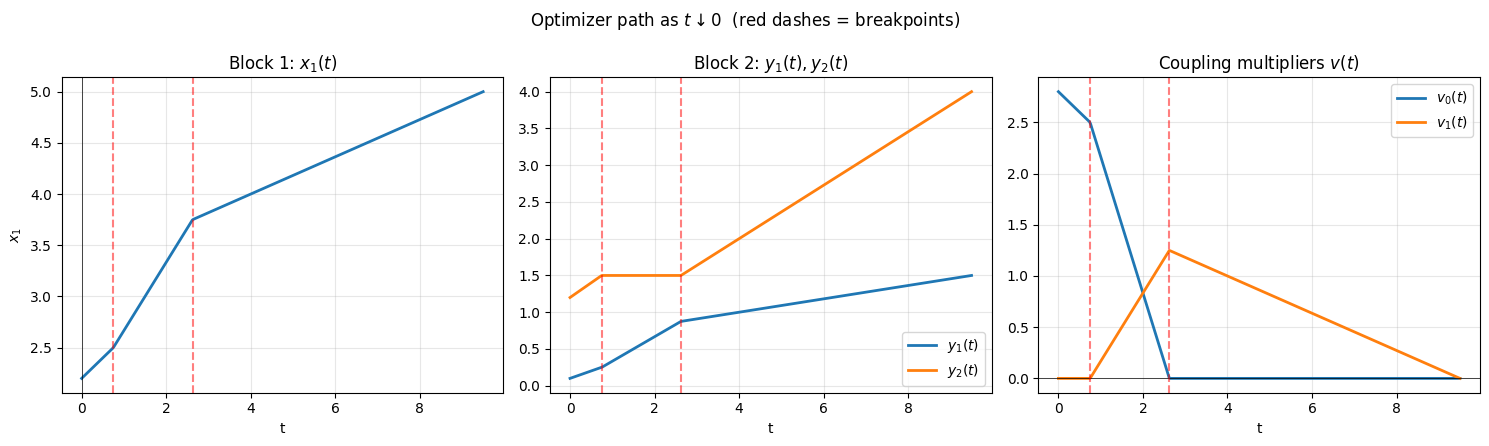

Optimum (at t = 0):
  x_1 = [2.2]
  x_2 = [0.1 1.2]


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ts_dense = np.linspace(0, segments[0].T_hi, 400)

# Helper: evaluate a piecewise-affine path at a vector of t-values
def evaluate(component_of):
    out = np.zeros_like(ts_dense)
    for k, t in enumerate(ts_dense):
        for seg in segments:
            if seg.T_lo - 1e-12 <= t <= seg.T_hi + 1e-12:
                out[k] = component_of(seg, t); break
    return out

# --- Block 1 (scalar x_1) ---
ax = axes[0]
ax.plot(ts_dense, evaluate(lambda s,t: s.x_at(0, t)[0]), lw=2, label="$x_1(t)$")
ax.set_xlabel("t"); ax.set_ylabel("$x_1$"); ax.set_title("Block 1: $x_1(t)$")
ax.axvline(0, color="k", lw=0.5); ax.grid(alpha=0.3)

# --- Block 2 (x_2 in R^2: y_1, y_2 vs t) ---
ax = axes[1]
ax.plot(ts_dense, evaluate(lambda s,t: s.x_at(1, t)[0]), lw=2, label="$y_1(t)$")
ax.plot(ts_dense, evaluate(lambda s,t: s.x_at(1, t)[1]), lw=2, label="$y_2(t)$")
ax.set_xlabel("t"); ax.set_title("Block 2: $y_1(t), y_2(t)$")
ax.legend(); ax.grid(alpha=0.3)

# --- Coupling multipliers v(t) ---
ax = axes[2]
for r in range(P.m0):
    vals = np.zeros_like(ts_dense)
    for k, t in enumerate(ts_dense):
        for seg in segments:
            if seg.T_lo - 1e-12 <= t <= seg.T_hi + 1e-12:
                I0_list = sorted(seg.I0)
                if r in I0_list:
                    idx = I0_list.index(r)
                    vals[k] = seg.v_at(t)[idx]
                else:
                    vals[k] = 0.0
                break
    ax.plot(ts_dense, vals, lw=2, label=f"$v_{r}(t)$")
ax.set_xlabel("t"); ax.set_title("Coupling multipliers $v(t)$")
ax.legend(); ax.grid(alpha=0.3); ax.axhline(0, color="k", lw=0.5)

# Mark the breakpoints on all three subplots
for ax in axes:
    for seg in segments:
        if seg.T_lo > 1e-12:
            ax.axvline(seg.T_lo, color="red", ls="--", alpha=0.5)

plt.suptitle("Optimizer path as $t \\downarrow 0$  (red dashes = breakpoints)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("Optimum (at t = 0):")
print(f"  x_1 = {x_star[0]}")
print(f"  x_2 = {x_star[1]}")

## Sanity check — the simple 2-scalar example

The same solver on the toy problem from the note:

$$
\max\ (4 x_1 - \tfrac12 x_1^2) + (3 x_2 - \tfrac12 x_2^2)
\quad\text{s.t.}\quad x_1 + x_2 \le 5,\quad x_1 \ge 3.4.
$$

Expected answer: $x^\star = (3.4,\ 1.6)$, with two segments and a kink at
$t = 0.8$ where the local bound activates.

In [11]:
P_toy = Problem(
    C = [np.array([[1.0]]), np.array([[1.0]])],
    c = [np.array([4.0]),   np.array([3.0])],
    A = [np.array([[1.0]]), np.array([[1.0]])],
    B = [np.array([[-1.0]]), np.zeros((0, 1))],   # x1 >= 3.4  iff  -x1 <= -3.4
    b0 = np.array([5.0]),
    b  = [np.array([-3.4]), np.zeros(0)],
)

segs_toy, x_toy = solve(P_toy, verbose=True)
print(f"\nOptimum: x = ({x_toy[0][0]}, {x_toy[1][0]})   "
      f"[expected (3.4, 1.6)]")

t_0 = 2
e_0 = [1.],  e_j = [[np.float64(0.0)], []]
initial I_0 = {0}, I_j = [set(), set()]

--- segment 0: t in [0.8, 2] ---
I_0 = {0}, I_j = [set(), set()]
  x_0(t) = [3.] + [0.5] t
  x_1(t) = [2.] + [0.5] t
  v(t)  = [1.] + [-0.5] t
  next: add local row r=0 to block j=0 (slack hits 0)

--- segment 1: t in [0, 0.8] ---
I_0 = {0}, I_j = [{0}, set()]
  x_0(t) = [3.4] + [0.] t
  x_1(t) = [1.6] + [1.] t
  v(t)  = [1.4] + [-1.] t
  next: no blocker — interval extends to t = 0

Optimum: x = (3.4, 1.6)   [expected (3.4, 1.6)]


## What to change live

If you want to **show the algorithm reacting** during the conversation, here
are the cheapest knobs to turn on the main example:

- **Loosen a coupling cap** (`b0[0]`) and re-run — fewer segments, different
  active set.
- **Tighten a box** (`b1[0]`, the upper bound on $x_1$) and re-run — a local
  row enters earlier, adding a segment.
- **Shift a $c_j$** — moves the unconstrained max, changes which rows are
  violated.

A handy way: copy the cell below and edit one entry.

In [12]:
# Edit any one entry and re-run
b0_alt = np.array([3.0, 5.0])      # was [3.5, 5.0]: tighten coupling row 0
P_alt = Problem(C=[C1, C2], c=[c1, c2], A=[A1, A2], B=[B1, B2],
                b0=b0_alt, b=[b1, b2])
segs_alt, x_alt = solve(P_alt, verbose=False)
print(f"With b_0 = {b0_alt}:  optimum = {x_alt[0]}, {x_alt[1]}")
print(f"Number of segments: {len(segs_alt)}")

With b_0 = [3. 5.]:  optimum = [2.], [0. 1.]
Number of segments: 3


## Summary

For a fixed active set, every primal and dual variable is a straight line in
$t$. The four blocker conditions tell us when that line stops being valid; the
*largest* root below the current $t$ is the next event. We change the active
set there and repeat.

$$
\boxed{\text{Fixed active set} \Rightarrow x, u, v \text{ affine in } t;
\quad \text{first zero slack/multiplier changes the active set.}}
$$